In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA

In [61]:
# settings for this experiment

country_min_count = 10
main_cat_min_count = 20
state_min_count = 20
region_min_count = 20
city_min_count = 30
C_values = [0.01, 0.1, 1, 10, 100]
N_TRIALS = 30
TIMEOUT_SECONDS = 1800

In [62]:
df = pd.read_csv("big_startup_secsees_dataset.csv")
print("raw shape:", df.shape)
df.head()

raw shape: (66368, 14)


,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24


In [63]:
# same target as the first baseline

good_status = ["closed", "acquired", "ipo"]
data = df[df["status"].isin(good_status)].copy()
data["target"] = 0
data.loc[data["status"].isin(["acquired", "ipo"]), "target"] = 1

print("labelled shape:", data.shape)
print(data["target"].value_counts())

labelled shape: (13334, 15)
target
1    7096
0    6238
Name: count, dtype: int64


In [64]:
# duplicate checks

print("duplicate rows:", data.duplicated().sum())
print("duplicate permalinks:", data["permalink"].duplicated().sum())

name_check = data["name"].fillna("").str.lower().str.strip()
home_check = data["homepage_url"].fillna("").str.lower().str.strip()

print("duplicate names:", name_check[name_check != ""].duplicated().sum())
print("duplicate homepages:", home_check[home_check != ""].duplicated().sum())

duplicate rows: 0
duplicate permalinks: 0
duplicate names: 11
duplicate homepages: 17


In [65]:
# funding

data["funding_num"] = data["funding_total_usd"].replace("-", np.nan)
data["funding_num"] = pd.to_numeric(data["funding_num"], errors="coerce")
data["funding_missing"] = data["funding_num"].isna().astype(int)
data["log_funding"] = np.log1p(data["funding_num"]) #some values are zero, so we use log1p to avoid -inf
data["funding_rounds"] = pd.to_numeric(data["funding_rounds"], errors="coerce")

In [66]:
# dates

data["founded_at"] = pd.to_datetime(data["founded_at"], errors="coerce")
data["first_funding_at"] = pd.to_datetime(data["first_funding_at"], errors="coerce")
data["last_funding_at"] = pd.to_datetime(data["last_funding_at"], errors="coerce")

# a few dates are clearly broken, so I set those to missing
for col in ["founded_at", "first_funding_at", "last_funding_at"]:
    bad_date = (data[col].dt.year < 1900) | (data[col].dt.year > 2016) #1900 is arbitrary, startups in the dataset shouldnt be founded before that, 2016 is the last year of data collection
    data.loc[bad_date, col] = pd.NaT

data["founded_missing"] = data["founded_at"].isna().astype(int)
data["first_funding_missing"] = data["first_funding_at"].isna().astype(int)
data["last_funding_missing"] = data["last_funding_at"].isna().astype(int)

data["founded_year"] = data["founded_at"].dt.year
data["first_year"] = data["first_funding_at"].dt.year
data["last_year"] = data["last_funding_at"].dt.year

data["first_gap"] = (data["first_funding_at"] - data["founded_at"]).dt.days
data["funding_days"] = (data["last_funding_at"] - data["first_funding_at"]).dt.days
data["startup_days"] = (data["last_funding_at"] - data["founded_at"]).dt.days

data["bad_first_gap"] = (data["first_gap"] < 0).fillna(False).astype(int)
data.loc[data["first_gap"] < 0, "first_gap"] = np.nan
data["bad_funding_days"] = (data["funding_days"] < 0).fillna(False).astype(int)
data.loc[data["funding_days"] < 0, "funding_days"] = np.nan
data["bad_startup_days"] = (data["startup_days"] < 0).fillna(False).astype(int)
data.loc[data["startup_days"] < 0, "startup_days"] = np.nan

In [67]:
# category count is needed for the correlation check

data["main_cat"] = data["category_list"].fillna("MISSING").str.split("|").str[0]
data["n_cat"] = data["category_list"].fillna("").str.count(r"\|") + data["category_list"].notna().astype(int)

In [68]:
# Spearman correlation before choosing the final date columns

corr_cols = [
    "funding_rounds",
    "log_funding",
    "founded_year",
    "first_year",
    "last_year",
    "first_gap",
    "funding_days",
    "startup_days",
    "n_cat",
]

corr = data[corr_cols].corr(method="spearman")
print(corr.round(3))

pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        value = corr.iloc[i, j]
        if abs(value) >= 0.8:
            pairs.append([corr_cols[i], corr_cols[j], value])

high_corr = pd.DataFrame(pairs, columns=["var1", "var2", "spearman"])
high_corr

                funding_rounds  log_funding  founded_year  first_year  \
funding_rounds           1.000        0.495        -0.162      -0.241   
log_funding              0.495        1.000        -0.565      -0.446   
founded_year            -0.162       -0.565         1.000       0.695   
first_year              -0.241       -0.446         0.695       1.000   
last_year                0.170       -0.138         0.553       0.841   
first_gap               -0.008        0.405        -0.732      -0.183   
funding_days             0.969        0.517        -0.217      -0.291   
startup_days             0.356        0.639        -0.786      -0.336   
n_cat                    0.085       -0.151         0.205       0.056   

                last_year  first_gap  funding_days  startup_days  n_cat  
funding_rounds      0.170     -0.008         0.969         0.356  0.085  
log_funding        -0.138      0.405         0.517         0.639 -0.151  
founded_year        0.553     -0.732        -0.

,var1,var2,spearman
0,funding_rounds,funding_days,0.968893
1,first_year,last_year,0.840761
2,first_gap,startup_days,0.852869


In [69]:
# category and location columns
# this is the bigger feature version compared with the first baseline

data["country_small"] = data["country_code"].fillna("MISSING")
country_counts = data["country_small"].value_counts()
keep_country = country_counts[country_counts >= country_min_count].index
data.loc[~data["country_small"].isin(keep_country), "country_small"] = "OTHER"

data["main_cat_small"] = data["main_cat"].fillna("MISSING")
cat_counts = data["main_cat_small"].value_counts()
keep_cat = cat_counts[cat_counts >= main_cat_min_count].index
data.loc[~data["main_cat_small"].isin(keep_cat), "main_cat_small"] = "OTHER"

data["state_small"] = data["state_code"].fillna("MISSING")
state_counts = data["state_small"].value_counts()
keep_state = state_counts[state_counts >= state_min_count].index
data.loc[~data["state_small"].isin(keep_state), "state_small"] = "OTHER"

data["region_small"] = data["region"].fillna("MISSING")
region_counts = data["region_small"].value_counts()
keep_region = region_counts[region_counts >= region_min_count].index
data.loc[~data["region_small"].isin(keep_region), "region_small"] = "OTHER"

data["city_small"] = data["city"].fillna("MISSING")
city_counts = data["city_small"].value_counts()
keep_city = city_counts[city_counts >= city_min_count].index
data.loc[~data["city_small"].isin(keep_city), "city_small"] = "OTHER"

print("country levels:", data["country_small"].nunique())
print("category levels:", data["main_cat_small"].nunique())
print("state levels:", data["state_small"].nunique())
print("region levels:", data["region_small"].nunique())
print("city levels:", data["city_small"].nunique())

country levels: 38
category levels: 94
state levels: 66
region levels: 82
city levels: 63


In [70]:
# final features for experiment B
# last_funding_at based columns are not used here

num_cols = [
    "funding_rounds",
    "log_funding",
    "funding_missing",
    "founded_year",
    "first_year",
    "first_gap",
    "founded_missing",
    "first_funding_missing",
    "bad_first_gap",
    "n_cat",
]

cat_cols = [
    "country_small",
    "main_cat_small",
    "state_small",
    "region_small",
    "city_small",
]

X = data[num_cols + cat_cols].copy()
y = data["target"].copy()

print("raw columns:", X.shape[1])
print("numeric:", len(num_cols), "categorical:", len(cat_cols))

raw columns: 15
numeric: 10 categorical: 5


In [71]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=1,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.25,
    stratify=y_trainval,
    random_state=1,
)

print("train:", X_train.shape)
print("val:", X_val.shape)
print("test:", X_test.shape)

train: (8000, 15)
val: (2667, 15)
test: (2667, 15)


In [72]:
# same preprocessing for the logistic baseline

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

prep = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])

In [73]:
# logistic regression baseline
# this is fast, so I just print the small table

rows = []

for C in C_values:
    model = Pipeline([
        ("prep", prep),
        ("model", LogisticRegression(C=C, max_iter=1000, solver="liblinear")),
    ])

    model.fit(X_train, y_train)
    prob = model.predict_proba(X_val)[:, 1]
    pred = model.predict(X_val)

    rows.append({
        "C": C,
        "val_auc": roc_auc_score(y_val, prob),
        "val_f1": f1_score(y_val, pred),
        "val_acc": accuracy_score(y_val, pred),
    })

base_res = pd.DataFrame(rows)
print(base_res)

best_C = base_res.sort_values("val_auc", ascending=False).iloc[0]["C"]
print("best C:", best_C)

        C   val_auc    val_f1   val_acc
0    0.01  0.810968  0.758148  0.735658
1    0.10  0.814864  0.765583  0.740532
2    1.00  0.811824  0.756885  0.731909
3   10.00  0.807163  0.755948  0.730784
4  100.00  0.804803  0.755102  0.730034
best C: 0.1


In [74]:
base_model = Pipeline([
    ("prep", prep),
    ("model", LogisticRegression(C=best_C, max_iter=1000, solver="liblinear")),
])

base_model.fit(X_trainval, y_trainval)

base_train_prob = base_model.predict_proba(X_trainval)[:, 1]
base_test_prob = base_model.predict_proba(X_test)[:, 1]

base_train_pred = base_model.predict(X_trainval)
base_test_pred = base_model.predict(X_test)

print("baseline train auc:", roc_auc_score(y_trainval, base_train_prob))
print("baseline test auc:", roc_auc_score(y_test, base_test_prob))
print("baseline test f1:", f1_score(y_test, base_test_pred))
print("baseline test acc:", accuracy_score(y_test, base_test_pred))
print(confusion_matrix(y_test, base_test_pred))

baseline train auc: 0.8289402126430065
baseline test auc: 0.8250424075278727
baseline test f1: 0.7726194510335479
baseline test acc: 0.7484064491938508
[[ 856  392]
 [ 279 1140]]


In [75]:
# number of one-hot columns in the logistic model

base_model.named_steps["prep"].fit(X_trainval)
print("model inputs after preprocessing:", len(base_model.named_steps["prep"].get_feature_names_out()))

model inputs after preprocessing: 353


In [76]:
# 3d PCA view, draggable in the notebook
# I only plot a sample so this cell does not become too slow

rng = np.random.default_rng(1)
plot_index = rng.choice(X_trainval.index, size=min(2000, len(X_trainval)), replace=False)

X_plot = base_model.named_steps["prep"].transform(X_trainval.loc[plot_index])

if hasattr(X_plot, "toarray"):
    X_plot = X_plot.toarray()

pca = PCA(n_components=3, random_state=1)
X_pca = pca.fit_transform(X_plot)

pca_df = pd.DataFrame({
    "pc1": X_pca[:, 0],
    "pc2": X_pca[:, 1],
    "pc3": X_pca[:, 2],
    "target": y_trainval.loc[plot_index].astype(str).values,
})

fig = px.scatter_3d(
    pca_df,
    x="pc1",
    y="pc2",
    z="pc3",
    color="target",
    opacity=0.5,
)

fig.show()
print("explained variance:", pca.explained_variance_ratio_)

explained variance: [0.18007828 0.1233166  0.10976859]


In [77]:
# CatBoost uses the same selected columns
# it can take the categorical columns without one-hot encoding

X_cb_train = X_train.copy()
X_cb_val = X_val.copy()
X_cb_trainval = X_trainval.copy()
X_cb_test = X_test.copy()

for col in cat_cols:
    X_cb_train[col] = X_cb_train[col].fillna("MISSING").astype(str)
    X_cb_val[col] = X_cb_val[col].fillna("MISSING").astype(str)
    X_cb_trainval[col] = X_cb_trainval[col].fillna("MISSING").astype(str)
    X_cb_test[col] = X_cb_test[col].fillna("MISSING").astype(str)

cat_features = [X_cb_train.columns.get_loc(col) for col in cat_cols]

In [78]:
# first CatBoost run before tuning

cat_plain = CatBoostClassifier(
    iterations=800,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=1,
    verbose=0,
    allow_writing_files=False,
)

cat_plain.fit(
    X_cb_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_cb_val, y_val),
    early_stopping_rounds=100,
    verbose=0,
)

plain_prob = cat_plain.predict_proba(X_cb_val)[:, 1]
print("plain catboost val auc:", roc_auc_score(y_val, plain_prob))

plain catboost val auc: 0.8369162329918143


In [79]:
import optuna

# Optuna tuning for CatBoost
# this is the slow part, so we print each trial

def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 500, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 30, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.001, 10, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 5),
        "border_count": trial.suggest_categorical("border_count", [32, 64, 128, 254]),
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "auto_class_weights": "Balanced",
        "random_seed": 1,
        "verbose": 0,
        "allow_writing_files": False,
    }

    print("trial", trial.number + 1, "/", N_TRIALS)

    model = CatBoostClassifier(**params)
    model.fit(
        X_cb_train,
        y_train,
        cat_features=cat_features,
        eval_set=(X_cb_val, y_val),
        early_stopping_rounds=100,
        verbose=0,
    )

    prob = model.predict_proba(X_cb_val)[:, 1]
    auc = roc_auc_score(y_val, prob)

    print("val auc:", round(auc, 4))
    return auc

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=N_TRIALS, timeout=TIMEOUT_SECONDS)

print("best val auc:", study.best_value)
print(study.best_params)

[I 2026-06-08 02:08:04,453] A new study created in memory with name: no-name-1e65800a-a84b-4f55-9c3b-a13fd0a5db58


trial 1 / 30


[I 2026-06-08 02:08:23,218] Trial 0 finished with value: 0.8347952919173849 and parameters: {'iterations': 602, 'learning_rate': 0.060595735769329244, 'depth': 7, 'l2_leaf_reg': 9.381151302036544, 'random_strength': 0.0013409874027643987, 'bagging_temperature': 2.7836342676183827, 'border_count': 32}. Best is trial 0 with value: 0.8347952919173849.


val auc: 0.8348
trial 2 / 30


[I 2026-06-08 02:09:25,839] Trial 1 finished with value: 0.8347043783090294 and parameters: {'iterations': 1482, 'learning_rate': 0.020858311519981246, 'depth': 4, 'l2_leaf_reg': 1.874060350328418, 'random_strength': 4.596638915203904, 'bagging_temperature': 2.2275996470923296, 'border_count': 254}. Best is trial 0 with value: 0.8347952919173849.


...

val auc: 0.8349
trial 29 / 30


[I 2026-06-08 02:30:16,059] Trial 28 finished with value: 0.8350109999819302 and parameters: {'iterations': 1603, 'learning_rate': 0.018610654348521775, 'depth': 6, 'l2_leaf_reg': 4.8588262358417085, 'random_strength': 0.16004060049936378, 'bagging_temperature': 3.171662774228552, 'border_count': 64}. Best is trial 17 with value: 0.8364605355884426.


val auc: 0.835
trial 30 / 30


[I 2026-06-08 02:31:44,487] Trial 29 finished with value: 0.8339318949784066 and parameters: {'iterations': 1696, 'learning_rate': 0.012849877287673965, 'depth': 7, 'l2_leaf_reg': 7.909570737876317, 'random_strength': 2.6502653249708317, 'bagging_temperature': 3.9420112248678367, 'border_count': 64}. Best is trial 17 with value: 0.8364605355884426.


val auc: 0.8339
best val auc: 0.8364605355884426
{'iterations': 1774, 'learning_rate': 0.0158415482583291, 'depth': 6, 'l2_leaf_reg': 3.003498914055919, 'random_strength': 1.3624368663394157, 'bagging_temperature': 4.042674483706165, 'border_count': 64}


In [80]:
# final CatBoost model

best_params = study.best_params.copy()

cat_final = CatBoostClassifier(
    **best_params,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=1,
    verbose=100,
    allow_writing_files=False,
)

cat_features_final = [X_cb_trainval.columns.get_loc(col) for col in cat_cols]

cat_final.fit(
    X_cb_trainval,
    y_trainval,
    cat_features=cat_features_final,
)

cat_train_prob = cat_final.predict_proba(X_cb_trainval)[:, 1]
cat_test_prob = cat_final.predict_proba(X_cb_test)[:, 1]

cat_train_pred = cat_final.predict(X_cb_trainval)
cat_test_pred = cat_final.predict(X_cb_test)

print("catboost train auc:", roc_auc_score(y_trainval, cat_train_prob))
print("catboost test auc:", roc_auc_score(y_test, cat_test_prob))
print("catboost test f1:", f1_score(y_test, cat_test_pred))
print("catboost test acc:", accuracy_score(y_test, cat_test_pred))
print(confusion_matrix(y_test, cat_test_pred))

0:	total: 65.7ms	remaining: 1m 56s
100:	total: 8.34s	remaining: 2m 18s
200:	total: 16.3s	remaining: 2m 7s
300:	total: 24.2s	remaining: 1m 58s
400:	total: 32.1s	remaining: 1m 50s
500:	total: 40.1s	remaining: 1m 41s
600:	total: 48.3s	remaining: 1m 34s
700:	total: 56.5s	remaining: 1m 26s
800:	total: 1m 4s	remaining: 1m 18s
900:	total: 1m 12s	remaining: 1m 10s
1000:	total: 1m 21s	remaining: 1m 2s
1100:	total: 1m 29s	remaining: 54.6s
1200:	total: 1m 37s	remaining: 46.6s
1300:	total: 1m 45s	remaining: 38.5s
1400:	total: 1m 54s	remaining: 30.4s
1500:	total: 2m 2s	remaining: 22.3s
1600:	total: 2m 10s	remaining: 14.1s
1700:	total: 2m 18s	remaining: 5.96s
1773:	total: 2m 24s	remaining: 0us
catboost train auc: 0.8766212714313601
catboost test auc: 0.8355002958927377
catboost test f1: 0.7691242644513673
catboost test acc: 0.7499062617172854
[[ 889  359]
 [ 308 1111]]


In [81]:
imp = pd.DataFrame({
    "feature": X_cb_trainval.columns,
    "importance": cat_final.get_feature_importance(),
})

imp = imp.sort_values("importance", ascending=False)
imp.head(15)

,feature,importance
1,log_funding,18.506875
4,first_year,15.154237
11,main_cat_small,12.854527
5,first_gap,8.411242
3,founded_year,7.865684
9,n_cat,6.852250
10,country_small,6.713510
13,region_small,5.902930
14,city_small,5.802574
0,funding_rounds,5.219752


In [82]:
print("baseline test auc:", roc_auc_score(y_test, base_test_prob))
print("catboost test auc:", roc_auc_score(y_test, cat_test_prob))
print("difference:", roc_auc_score(y_test, cat_test_prob) - roc_auc_score(y_test, base_test_prob))

baseline test auc: 0.8250424075278727
catboost test auc: 0.8355002958927377
difference: 0.010457888364864942


# Validation experiments

The earlier cells already have the baseline and tuned CatBoost result. I added the cells below to check the model a bit more and see why the accuracy does not improve that much.

Things below are:
1. put the one-split test result in a small table
2. check the train-test gap and learning curve
3. do cross-validation using the parameters found above
4. check uncertainty from the fold models
5. check calibration and a few feature sets


In [83]:
# more stuff to import
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import brier_score_loss
from sklearn.metrics import log_loss

out_path = "presentation_experiment_outputs"
os.makedirs(out_path, exist_ok=True)

## Experiment 1: one-split result

This puts the earlier 80/20 test result into a small table for logistic regression and CatBoost.


In [84]:
rows = []

rows.append({
    "model": "logistic baseline",
    "test_auc": roc_auc_score(y_test, base_test_prob),
    "test_f1": f1_score(y_test, base_test_pred),
    "test_acc": accuracy_score(y_test, base_test_pred),
})

rows.append({
    "model": "catboost tuned",
    "test_auc": roc_auc_score(y_test, cat_test_prob),
    "test_f1": f1_score(y_test, cat_test_pred),
    "test_acc": accuracy_score(y_test, cat_test_pred),
})

df_split = pd.DataFrame(rows)
df_split["auc_minus_baseline"] = df_split["test_auc"] - df_split.loc[0, "test_auc"]
df_split.to_csv(os.path.join(out_path, "one_split_test_result.csv"), index=False)
df_split

,model,test_auc,test_f1,test_acc,auc_minus_baseline
0,logistic baseline,0.825042,0.772619,0.748406,0.000000
1,catboost tuned,0.835500,0.769124,0.749906,0.010458


In [85]:
# check the train-test gap

rows = []

rows.append({
    "model": "logistic baseline",
    "train_auc": roc_auc_score(y_trainval, base_train_prob),
    "test_auc": roc_auc_score(y_test, base_test_prob),
    "train_f1": f1_score(y_trainval, base_train_pred),
    "test_f1": f1_score(y_test, base_test_pred),
    "train_acc": accuracy_score(y_trainval, base_train_pred),
    "test_acc": accuracy_score(y_test, base_test_pred),
})

rows.append({
    "model": "catboost tuned",
    "train_auc": roc_auc_score(y_trainval, cat_train_prob),
    "test_auc": roc_auc_score(y_test, cat_test_prob),
    "train_f1": f1_score(y_trainval, cat_train_pred),
    "test_f1": f1_score(y_test, cat_test_pred),
    "train_acc": accuracy_score(y_trainval, cat_train_pred),
    "test_acc": accuracy_score(y_test, cat_test_pred),
})

check_df = pd.DataFrame(rows)
check_df["auc_gap"] = check_df["train_auc"] - check_df["test_auc"]
check_df["f1_gap"] = check_df["train_f1"] - check_df["test_f1"]
check_df["acc_gap"] = check_df["train_acc"] - check_df["test_acc"]

notes = []
for _, row in check_df.iterrows():
    if row["train_auc"] < 0.70 and row["test_auc"] < 0.70:
        notes.append("possible underfitting")
    elif row["auc_gap"] > 0.1:
        notes.append("possible overfitting")
    else:
        notes.append("no large train-test gap")

check_df["rough_check"] = notes
check_df.to_csv(os.path.join(out_path, "one_split_fit_check.csv"), index=False)
check_df.round(4)

,model,train_auc,test_auc,train_f1,test_f1,train_acc,test_acc,auc_gap,f1_gap,acc_gap,rough_check
0,logistic baseline,0.8289,0.8250,0.7717,0.7726,0.7481,0.7484,0.0039,-0.0009,-0.0003,no large train-test gap
1,catboost tuned,0.8766,0.8355,0.8038,0.7691,0.7881,0.7499,0.0411,0.0347,0.0382,no large train-test gap


In [100]:
# plot learning curve

X_lc_train, X_lc_val, y_lc_train, y_lc_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.2,
    stratify=y_trainval,
    random_state=1,
)

sizes = [0.2, 0.4, 0.6, 0.8, 1]
rows = []

for size in sizes:
    print("training size:", size)

    if size < 1:
        X_part, _, y_part, _ = train_test_split(
            X_lc_train,
            y_lc_train,
            train_size=size,
            stratify=y_lc_train,
            random_state=1,
        )
    else:
        X_part = X_lc_train.copy()
        y_part = y_lc_train.copy()

    X_part_cb = X_part.copy()
    X_lc_val_cb = X_lc_val.copy()

    for col in cat_cols:
        X_part_cb[col] = X_part_cb[col].fillna("MISSING").astype(str)
        X_lc_val_cb[col] = X_lc_val_cb[col].fillna("MISSING").astype(str)

    cat_features = [X_part_cb.columns.get_loc(col) for col in cat_cols]

    lc_params = best_params.copy()
    lc_params["iterations"] = 500
    lc_params["loss_function"] = "Logloss"
    lc_params["eval_metric"] = "AUC"
    lc_params["auto_class_weights"] = "Balanced"
    lc_params["random_seed"] = 1
    lc_params["verbose"] = 0
    lc_params["allow_writing_files"] = False

    model = CatBoostClassifier(**lc_params)

    model.fit(
        X_part_cb,
        y_part,
        cat_features=cat_features,
        eval_set=(X_lc_val_cb, y_lc_val),
        early_stopping_rounds=50,
        verbose=0,
    )

    train_prob = model.predict_proba(X_part_cb)[:, 1]
    val_prob = model.predict_proba(X_lc_val_cb)[:, 1]

    rows.append({
        "train_fraction": size,
        "train_rows": len(X_part_cb),
        "train_auc": roc_auc_score(y_part, train_prob),
        "val_auc": roc_auc_score(y_lc_val, val_prob),
    })

learn_df = pd.DataFrame(rows)
learn_df["auc_gap"] = learn_df["train_auc"] - learn_df["val_auc"]

learn_df.to_csv(
    os.path.join(out_path, "learning_curve.csv"),
    index=False,
)

learn_df.round(4)

training size: 0.2
training size: 0.4
training size: 0.6
training size: 0.8
training size: 1


,train_fraction,train_rows,train_auc,val_auc,auc_gap
0,0.2,1706,0.8149,0.8043,0.0106
1,0.4,3413,0.8647,0.8164,0.0483
2,0.6,5119,0.8582,0.8217,0.0365
3,0.8,6826,0.8531,0.8218,0.0314
4,1.0,8533,0.8551,0.8233,0.0318


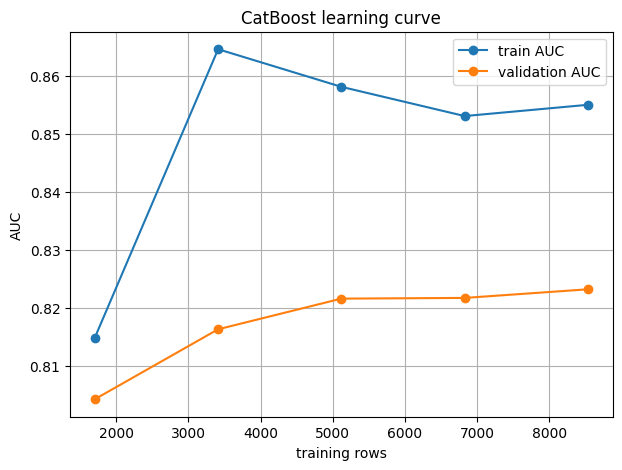

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(
    learn_df["train_rows"],
    learn_df["train_auc"],
    marker="o",
    label="train AUC",
)

plt.plot(
    learn_df["train_rows"],
    learn_df["val_auc"],
    marker="o",
    label="validation AUC",
)

plt.xlabel("training rows")
plt.ylabel("AUC")
plt.title("CatBoost learning curve")
plt.legend()
plt.grid()

plt.savefig(
    os.path.join(out_path, "learning_curve.png"),
    bbox_inches="tight",
)
plt.savefig(os.path.join(out_path, "learning_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

## Experiment 2: cross-validation

Now we run cv by keeping the test set untouched and rotate the train/val split inside X_trainval. For each fold I retrain logistic regression and CatBoost. This checks whether the result is stable and the CatBoost fold models are also used for the uncertainty check later.

In [88]:
cv_folds = 5
cv_stop = 50
cv_params = best_params.copy()
cv_params["loss_function"] = "Logloss"
cv_params["eval_metric"] = "AUC"
cv_params["auto_class_weights"] = "Balanced"
cv_params["verbose"] = 0
cv_params["allow_writing_files"] = False

In [89]:
# convenience functions on metrics

def score_row(model_name, fold, y_true, prob):
    pred = (prob >= 0.5).astype(int)

    return {
        "model": model_name,
        "fold": fold,
        "auc": roc_auc_score(y_true, prob),
        "f1": f1_score(y_true, pred),
        "acc": accuracy_score(y_true, pred),
        "brier": brier_score_loss(y_true, prob),
        "logloss": log_loss(y_true, prob, labels=[0, 1]),
    }

def make_cv_summary(res):
    rows = []
    metrics = ["auc", "f1", "acc", "brier", "logloss"]

    for model in res["model"].unique():
        part = res[res["model"] == model]

        for metric in metrics:
            vals = part[metric].values
            std = vals.std(ddof=1)

            rows.append({
                "model": model,
                "metric": metric,
                "mean": vals.mean(),
                "std": std,
                "ci95": 1.96 * std / np.sqrt(len(vals)),
            })

    return pd.DataFrame(rows)

In [90]:
# running cv

cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=1)
rows = []
cat_models = []
test_probs = []
test_logits = []

for fold, (train_index, val_index) in enumerate(cv.split(X_trainval, y_trainval), start=1):
    print("fold", fold, "of", cv_folds)

    X_tr = X_trainval.iloc[train_index].copy()
    X_va = X_trainval.iloc[val_index].copy()
    y_tr = y_trainval.iloc[train_index].copy()
    y_va = y_trainval.iloc[val_index].copy()

    # logistic
    base_cv = Pipeline([
        ("prep", prep),
        ("model", LogisticRegression(C=best_C, max_iter=1000, solver="liblinear")),
    ])

    base_cv.fit(X_tr, y_tr)
    base_prob = base_cv.predict_proba(X_va)[:, 1]
    rows.append(score_row("logistic", fold, y_va, base_prob))

    # CatBoost
    X_tr_cb = X_tr.copy()
    X_va_cb = X_va.copy()
    X_test_cb = X_test.copy()

    for col in cat_cols:
        X_tr_cb[col] = X_tr_cb[col].fillna("MISSING").astype(str)
        X_va_cb[col] = X_va_cb[col].fillna("MISSING").astype(str)
        X_test_cb[col] = X_test_cb[col].fillna("MISSING").astype(str)

    cat_features = [X_tr_cb.columns.get_loc(col) for col in cat_cols]

    params = cv_params.copy()
    params["random_seed"] = 1

    cat_cv = CatBoostClassifier(**params)
    cat_cv.fit(
        X_tr_cb,
        y_tr,
        cat_features=cat_features,
        eval_set=(X_va_cb, y_va),
        early_stopping_rounds=cv_stop,
        verbose=0,
    )

    cat_prob = cat_cv.predict_proba(X_va_cb)[:, 1]
    rows.append(score_row("catboost", fold, y_va, cat_prob))

    # save for uncertainty
    test_prob = cat_cv.predict_proba(X_test_cb)[:, 1]
    test_logit = cat_cv.predict(X_test_cb, prediction_type="RawFormulaVal")
    test_logit = np.ravel(test_logit)

    test_probs.append(test_prob)
    test_logits.append(test_logit)
    cat_models.append(cat_cv)

cv_df = pd.DataFrame(rows)
cv_table = make_cv_summary(cv_df)
cv_df

fold 1 of 5
fold 2 of 5
fold 3 of 5
fold 4 of 5
fold 5 of 5


,model,fold,auc,f1,acc,brier,logloss
0,logistic,1,0.810917,0.762267,0.736645,0.174907,0.522359
1,catboost,1,0.825015,0.761822,0.742737,0.169398,0.505048
2,logistic,2,0.820332,0.765464,0.744142,0.171034,0.513386
3,catboost,2,0.835370,0.773609,0.753983,0.164083,0.492624
4,logistic,3,0.811068,0.752000,0.723863,0.175450,0.524452
5,catboost,3,0.839614,0.771012,0.749648,0.161784,0.488530
6,logistic,4,0.824615,0.768048,0.745429,0.169135,0.508618
7,catboost,4,0.842067,0.779852,0.762307,0.160850,0.486347
8,logistic,5,0.818147,0.760000,0.735584,0.172831,0.518017
9,catboost,5,0.832506,0.763493,0.747304,0.166456,0.498745


In [91]:
# cv summary

cv_mean = cv_table.pivot(index="metric", columns="model", values="mean")
cv_mean.to_csv(os.path.join(out_path, "cv_summary_mean_wide.csv"))

print("mean scores")
print(cv_mean.round(4))

mean scores
model    catboost  logistic
metric                     
acc        0.7512    0.7371
auc        0.8349    0.8170
brier      0.1645    0.1727
f1         0.7700    0.7616
logloss    0.4943    0.5174


## Experiment 3: uncertainty

The cross-validation step gives five CatBoost models. For each test row, I collect the five predicted probabilities and the five raw logits. The mean is used as the central prediction, and the standard deviation is used as a simple measure of fold-model disagreement.

Since this gives one uncertainty value per test row, I summarize the distribution of the standard deviations instead of only looking at one average.

In [92]:
# uncertainty from the five fold models

prob_arr = np.array(test_probs)
logit_arr = np.array(test_logits)

avg_prob = prob_arr.mean(axis=0)
std_prob = prob_arr.std(axis=0)

mean_logit = logit_arr.mean(axis=0)
std_logit = logit_arr.std(axis=0)

avg_pred = (avg_prob >= 0.5).astype(int)
correct = (avg_pred == y_test.values).astype(int)

unc_test = pd.DataFrame({
    "true": y_test.values,
    "pred": avg_pred,
    "mean_prob": avg_prob,
    "std_prob": std_prob,
    "mean_logit": mean_logit,
    "std_logit": std_logit,
    "correct": correct,
}, index=y_test.index)

cv_test_df = pd.DataFrame([{
    "model": "catboost cv mean",
    "test_auc": roc_auc_score(y_test, avg_prob),
    "test_f1": f1_score(y_test, avg_pred),
    "test_acc": accuracy_score(y_test, avg_pred),
    "test_brier": brier_score_loss(y_test, avg_prob),
    "test_logloss": log_loss(y_test, avg_prob, labels=[0, 1]),
}])

rows = []

for col in ["std_prob", "std_logit"]:
    rows.append({
        "quantity": col,
        "mean": unc_test[col].mean(),
        "median": unc_test[col].median(),
        "q75": unc_test[col].quantile(0.75),
        "q90": unc_test[col].quantile(0.9),
        "q95": unc_test[col].quantile(0.95),
        "max": unc_test[col].max(),
    })

unc_table = pd.DataFrame(rows)

top_unc = unc_test.sort_values("std_logit", ascending=False).head(5)

cv_test_df.to_csv(os.path.join(out_path, "catboost_cv_ensemble_test_result.csv"), index=False)
unc_table.to_csv(os.path.join(out_path, "uncertainty_summary.csv"), index=False)
top_unc.to_csv(os.path.join(out_path, "uncertain_examples.csv"))

print("CatBoost CV mean result")
display(cv_test_df.round(4))

print("uncertainty summary")
display(unc_table.round(4))

print("largest fold disagreeing rows")
display(top_unc[[
    "true",
    "pred",
    "mean_prob",
    "std_prob",
    "mean_logit",
    "std_logit",
    "correct",
]].round(4))

CatBoost CV mean result


,model,test_auc,test_f1,test_acc,test_brier,test_logloss
0,catboost cv mean,0.8382,0.7731,0.7544,0.1628,0.4931


uncertainty summary


,quantity,mean,median,q75,q90,q95,max
0,std_prob,0.0229,0.0210,0.0299,0.0394,0.0475,0.1532
1,std_logit,0.1462,0.1332,0.1788,0.2431,0.2818,0.6657


largest fold disagreeing rows


,true,pred,mean_prob,std_prob,mean_logit,std_logit,correct
8646,0,1,0.5736,0.1532,0.3268,0.6657,0
21974,1,1,0.5664,0.1316,0.2912,0.5593,1
21195,0,0,0.2032,0.0687,-1.4509,0.5497,1
7380,0,0,0.4958,0.1275,-0.0260,0.5361,1
4668,1,1,0.5760,0.1221,0.3328,0.5330,1


## Experiment 4: calibration
For example the 0.6 to 0.7 bin contains test rows where the model predicted success probability between 0.6 and 0.7. For each bin I compare the mean predicted probability with the observed success rate for that bin. If the model is calibrated well these two numbers should be close.


In [93]:
rows = []
bins = np.linspace(0, 1, 11)
bin_no = np.digitize(avg_prob, bins[1:-1], right=True)

for b in range(10):
    mask = bin_no == b

    if mask.sum() > 0:
        mean_prob = avg_prob[mask].mean()
        obs_rate = y_test.values[mask].mean()
        err = abs(mean_prob - obs_rate)

        rows.append({
            "bin": b,
            "left": bins[b],
            "right": bins[b + 1],
            "count": mask.sum(),
            "mean_predicted_prob": mean_prob,
            "observed_success_rate": obs_rate,
            "abs_error": err,
            "weighted_abs_error": err * mask.sum() / len(y_test),
        })

calib_table = pd.DataFrame(rows)
ece = calib_table["weighted_abs_error"].sum()

calib_table.to_csv(os.path.join(out_path, "calibration_table.csv"), index=False)
print("ECE:", round(ece, 4))
calib_table

ECE: 0.0267


,bin,left,right,count,mean_predicted_prob,observed_success_rate,abs_error,weighted_abs_error
0,0,0.0,0.1,325,0.042650,0.055385,0.012734,0.001552
1,1,0.1,0.2,192,0.151243,0.145833,0.005410,0.000389
2,2,0.2,0.3,205,0.248268,0.209756,0.038512,0.002960
3,3,0.3,0.4,220,0.350213,0.390909,0.040696,0.003357
4,4,0.4,0.5,257,0.452782,0.498054,0.045272,0.004363
5,5,0.5,0.6,296,0.552151,0.554054,0.001904,0.000211
6,6,0.6,0.7,265,0.651654,0.660377,0.008724,0.000867
7,7,0.7,0.8,382,0.752659,0.806283,0.053624,0.007681
8,8,0.8,0.9,389,0.850707,0.884319,0.033612,0.004903
9,9,0.9,1.0,136,0.927959,0.919118,0.008841,0.000451


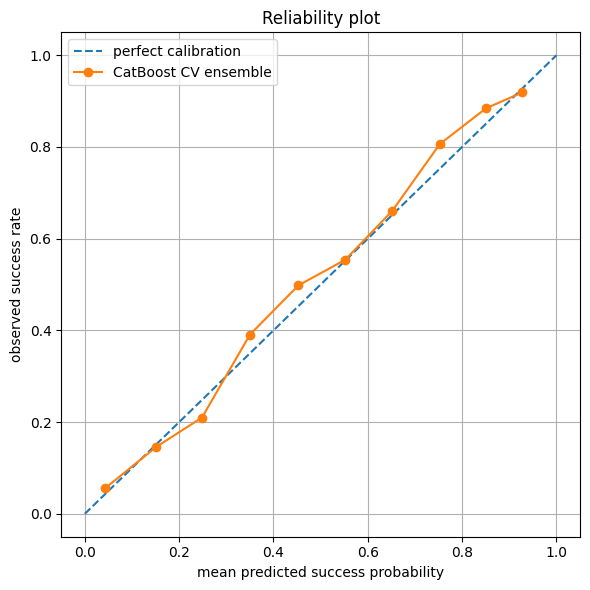

In [94]:
# reliability plot

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="perfect calibration")
plt.plot(
    calib_table["mean_predicted_prob"],
    calib_table["observed_success_rate"],
    marker="o",
    label="CatBoost CV ensemble",
)
plt.xlabel("mean predicted success probability")
plt.ylabel("observed success rate")
plt.title("Reliability plot")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(out_path, "reliability_plot.png"), dpi=200)
plt.show()


## Experiment 5: feature probing
This checks whether some feature changes changes the performance. The aim is to probe the dataset a bit more for some insights.

In [95]:
# some trial settings

exp_folds = 3
exp_iter = 500
exp_stop = 50

feat_sets = [
    {
        "name": "all_features",
        "num": num_cols,
        "cat": cat_cols,
    },
    {
        "name": "no_city",
        "num": num_cols,
        "cat": ["country_small", "main_cat_small", "state_small", "region_small"],
    },
    {
        "name": "geography_only",
        "num": [],
        "cat": ["country_small", "state_small", "region_small", "city_small"],
    },
    {
        "name": "no_funding_amount_or_rounds",
        "num": [c for c in num_cols if c not in ["funding_rounds", "log_funding", "funding_missing"]],
        "cat": cat_cols,
    },
    {
        "name": "early_basic_features",
        "num": ["founded_year", "founded_missing", "n_cat"],
        "cat": ["country_small", "main_cat_small", "state_small"],
    },
]

exp_params = cv_params.copy()
exp_params["iterations"] = min(int(exp_params.get("iterations", exp_iter)), exp_iter)
exp_params["verbose"] = 0

print(exp_params["iterations"])

500


In [96]:
# run

exp_cv = StratifiedKFold(n_splits=exp_folds, shuffle=True, random_state=1)
rows = []

for feat_set in feat_sets:
    print("feature set:", feat_set["name"])

    use_num = feat_set["num"]
    use_cat = feat_set["cat"]
    use_cols = use_num + use_cat

    X_exp = X_trainval[use_cols].copy()
    y_exp = y_trainval.copy()

    for fold, (train_index, val_index) in enumerate(exp_cv.split(X_exp, y_exp), start=1):
        X_tr = X_exp.iloc[train_index].copy()
        X_va = X_exp.iloc[val_index].copy()
        y_tr = y_exp.iloc[train_index].copy()
        y_va = y_exp.iloc[val_index].copy()

        # logistic
        num_pipe_exp = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ])

        cat_pipe_exp = Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ])

        prep_exp = ColumnTransformer([
            ("num", num_pipe_exp, use_num),
            ("cat", cat_pipe_exp, use_cat),
        ])

        base_exp = Pipeline([
            ("prep", prep_exp),
            ("model", LogisticRegression(C=best_C, max_iter=1000, solver="liblinear")),
        ])

        base_exp.fit(X_tr, y_tr)
        base_prob = base_exp.predict_proba(X_va)[:, 1]
        row = score_row("logistic", fold, y_va, base_prob)
        row["feature_set"] = feat_set["name"]
        rows.append(row)

        # CatBoost
        for col in use_cat:
            X_tr[col] = X_tr[col].fillna("MISSING").astype(str)
            X_va[col] = X_va[col].fillna("MISSING").astype(str)

        cat_features = [X_tr.columns.get_loc(col) for col in use_cat]

        params = exp_params.copy()
        params["random_seed"] = 1

        cat_exp = CatBoostClassifier(**params)
        cat_exp.fit(
            X_tr,
            y_tr,
            cat_features=cat_features,
            eval_set=(X_va, y_va),
            early_stopping_rounds=exp_stop,
            verbose=0,
        )

        cat_prob = cat_exp.predict_proba(X_va)[:, 1]
        row = score_row("catboost", fold, y_va, cat_prob)
        row["feature_set"] = feat_set["name"]
        rows.append(row)

feat_df = pd.DataFrame(rows)
feat_df.head()

feature set: all_features
feature set: no_city
feature set: geography_only
feature set: no_funding_amount_or_rounds
feature set: early_basic_features


,model,fold,auc,f1,acc,brier,logloss,feature_set
0,logistic,1,0.815770,0.766317,0.743251,0.173139,0.518504,all_features
1,catboost,1,0.825018,0.761830,0.743813,0.169695,0.508418,all_features
2,logistic,2,0.815978,0.760677,0.733690,0.172776,0.517016,all_features
3,catboost,2,0.833910,0.768391,0.749438,0.165057,0.498040,all_features
4,logistic,3,0.818758,0.764240,0.740366,0.172272,0.516987,all_features


In [97]:
# summary table

rows = []

for feat_name in feat_df["feature_set"].unique():
    for model in feat_df["model"].unique():
        part = feat_df[
            (feat_df["feature_set"] == feat_name)
            & (feat_df["model"] == model)
        ]

        rows.append({
            "feature_set": feat_name,
            "model": model,
            "auc_mean": part["auc"].mean(),
            "auc_std": part["auc"].std(ddof=1),
            "f1_mean": part["f1"].mean(),
            "acc_mean": part["acc"].mean(),
            "brier_mean": part["brier"].mean(),
        })

feat_table = pd.DataFrame(rows)
feat_table = feat_table.sort_values(["feature_set", "model"])
feat_table.to_csv(os.path.join(out_path, "feature_set_summary.csv"), index=False)
feat_table.round(4)

,feature_set,model,auc_mean,auc_std,f1_mean,acc_mean,brier_mean
1,all_features,catboost,0.8296,0.0045,0.7645,0.7468,0.1674
0,all_features,logistic,0.8168,0.0017,0.7637,0.7391,0.1727
9,early_basic_features,catboost,0.7799,0.0029,0.7311,0.7035,0.1896
8,early_basic_features,logistic,0.7719,0.0049,0.7382,0.6990,0.1925
5,geography_only,catboost,0.6929,0.0065,0.7192,0.6573,0.2187
4,geography_only,logistic,0.6941,0.0080,0.7200,0.6572,0.2153
3,no_city,catboost,0.8293,0.0039,0.7642,0.7463,0.1675
2,no_city,logistic,0.8166,0.0017,0.7635,0.7391,0.1729
7,no_funding_amount_or_rounds,catboost,0.7918,0.0054,0.7409,0.7148,0.1841
6,no_funding_amount_or_rounds,logistic,0.7758,0.0064,0.7399,0.7048,0.1904
